# **Install and Import Package**


In [1]:
%pip install requests
%pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
# Fix SSL certificate issue temporarily 
import ssl
import nltk
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
import time


# **Step 1: Crawl a Real-World Dataset**

In [3]:
import requests
import json
import numpy as np
import pandas as pd

In [4]:
subreddit = 'apple'
timeframe = 'year'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    

In [5]:
def get_reddit(subreddit, listing, limit, timeframe):
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request

def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    '''Get Reddit posts after a specific token (pagination).'''
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [6]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  2nd 100 posts 
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print('Page 2 posts:', len(children2))

for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  3rd 
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print('Page 3 posts:', len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)
top_reddit_posts['Upvotes'] = pd.to_numeric(top_reddit_posts['Upvotes'])
top_reddit_posts['Num_Comments'] = pd.to_numeric(top_reddit_posts['Num_Comments'])

print('Final combined shape:', top_reddit_posts.shape)
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 50
Final combined shape: (250, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13576,iPhone,1363,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11255,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8773,Apple Intelligence,611,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7784,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...
245,Shazam hits 100 billion song recognitions,1478,App Store,122,"""That’s 12 songs identified for every person o...",1732150658.0,1gw3nd6
246,Apple wants the iPhone 17 Pro to replace your ...,1474,iPhone,482,,1740369229.0,1iwt1cj
247,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,282,,1755179314.0,1mq172h
248,Apple announces chief operating officer transi...,1473,Apple Newsroom,162,,1752007424.0,1luzs4q


In [7]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print('Page 1 posts:', len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['score'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id'],
        ]
    )

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Score', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID',]
)

top100

Page 1 posts: 100


,Title,Upvotes,Score,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13579,13579,iPhone,1363,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11268,11268,Apple Intelligence,1431,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9867,9867,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8762,8762,Apple Intelligence,611,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7780,7780,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...,...
95,It’s time for Apple to modernize its iCloud st...,2385,2385,iCloud,303,,1736646771.0,1hzbxtf
96,Apple Reportedly Moving Ahead With Ads in Maps...,2372,2372,Rumor,1014,,1761486414.0,1ogl1dq
97,Apple intensifies succession planning for CEO ...,2370,2370,Discussion,546,[http://archive.today/d8s5h](http://archive.to...,1763181364.0,1oxijte
98,Trump Believes Apple Could Manufacture iPhones...,2360,2360,iPhone,662,,1744139593.0,1julvr8


# **Step 2: Perform data preparation and cleaning**

## 2.1 Add features column and Enrich Data

### 2.1.1 Convert Unix Timestamp to Real Date

In [8]:
#Convert UNIX Timestamp into Real Date
top_reddit_posts['Created_At'] = pd.to_datetime(top_reddit_posts['Created_UTC'], unit='s')

In [9]:
# Convert full timestamp into date column
top_reddit_posts['Created_Date'] = top_reddit_posts['Created_At'].dt.date #Extract calendar date
top_reddit_posts['Created_Time'] = top_reddit_posts['Created_At'].dt.time #Extract Time 

In [10]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13576,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10
1,Most iPhone owners see little to no value in A...,11255,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02
3,Apple sued for false advertising over Apple In...,8773,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06
4,Apple is racing to fly planes of iPhones into ...,7784,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56
...,...,...,...,...,...,...,...,...,...,...
245,Shazam hits 100 billion song recognitions,1478,App Store,122,"""That’s 12 songs identified for every person o...",1732150658.0,1gw3nd6,2024-11-21 00:57:38,2024-11-21,00:57:38
246,Apple wants the iPhone 17 Pro to replace your ...,1474,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49,2025-02-24,03:53:49
247,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34
248,Apple announces chief operating officer transi...,1473,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44


### 2.1.2 Add Setimental Analysis Features

In [11]:
 # Remove ALL old VADER columns if they exist (In case rerun the code)
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

# calculate new sentiment 
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })


sentimental_title = pd.DataFrame(results)

# Combine table 
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)
top_reddit_posts['Title_compound'] = pd.to_numeric(top_reddit_posts['Title_compound'])


sentimental_title

,Title_compound,Title_Sent
0,0.0000,Neutral
1,0.5130,Positive
2,-0.2960,Negative
3,0.4767,Positive
4,0.0000,Neutral
...,...,...
245,0.0000,Neutral
246,0.0000,Neutral
247,0.0000,Neutral
248,0.0000,Neutral


### 2.1.3 Add Word Count Features

In [12]:
# Title Word Count
top_reddit_posts['Title_Word_Count'] = top_reddit_posts['Title'].astype(str).str.split().str.len()

# Body Word Count
top_reddit_posts['Body_Word_Count'] = top_reddit_posts['Body'].astype(str).str.split().str.len()

## 2.2 Handle Data

### 2.2.1 Handle Missing Data

In [13]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna('None')
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna('')
top_reddit_posts


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13576,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10,0.0000,Neutral,14,0
1,Most iPhone owners see little to no value in A...,11255,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37,0.5130,Positive,13,0
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02,-0.2960,Negative,9,0
3,Apple sued for false advertising over Apple In...,8773,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06,0.4767,Positive,8,0
4,Apple is racing to fly planes of iPhones into ...,7784,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56,0.0000,Neutral,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Shazam hits 100 billion song recognitions,1478,App Store,122,"""That’s 12 songs identified for every person o...",1732150658.0,1gw3nd6,2024-11-21 00:57:38,2024-11-21,00:57:38,0.0000,Neutral,6,9
246,Apple wants the iPhone 17 Pro to replace your ...,1474,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49,2025-02-24,03:53:49,0.0000,Neutral,13,0
247,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34,0.0000,Neutral,11,0
248,Apple announces chief operating officer transi...,1473,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44,0.0000,Neutral,6,0


### 2.2.2 Identify & Handle Outliers

Check for Skewness

In [14]:
cols = ['Upvotes', 'Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Upvotes: 3.3581 --> Highly skewed
Num_Comments: 2.6224 --> Highly skewed
Title_compound: -0.1422 --> Approximately symmetric
Title_Word_Count: 2.5750 --> Highly skewed
Body_Word_Count: 7.5546 --> Highly skewed


**Use Log-Transform on the highly skewed features**

In [15]:
top_reddit_posts['Log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])
top_reddit_posts['Log_Num_Comments'] = np.log1p(top_reddit_posts['Num_Comments'])
top_reddit_posts['Log_Body_Word_Count'] = np.log1p(top_reddit_posts['Body_Word_Count'])

In [16]:
cols = ['Log_Upvotes', 'Log_Num_Comments', 'Title_compound', 'Title_Word_Count', 'Log_Body_Word_Count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()

    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = 'Highly skewed'
    elif abs(skew_value) > 0.5:
        interpretation = 'Moderately skewed'
    else:
        interpretation = 'Approximately symmetric'
    
    print(f'{col}: {skew_value:.4f} --> {interpretation}')

Log_Upvotes: 1.5054 --> Highly skewed
Log_Num_Comments: -1.9563 --> Highly skewed
Title_compound: -0.1422 --> Approximately symmetric
Title_Word_Count: 2.5750 --> Highly skewed
Log_Body_Word_Count: 3.1879 --> Highly skewed


In [17]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13576,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,2025-04-04,16:50:10,0.0000,Neutral,14,0,9.516132,7.218177,0.000000
1,Most iPhone owners see little to no value in A...,11255,Apple Intelligence,1431,,1734363217.0,1hflpje,2024-12-16 15:33:37,2024-12-16,15:33:37,0.5130,Positive,13,0,9.328657,7.266827,0.000000
2,Apple shareholders say no to scrapping company...,9872,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,2025-02-25,17:06:02,-0.2960,Negative,9,0,9.197559,6.553933,0.000000
3,Apple sued for false advertising over Apple In...,8773,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,2025-03-20,22:27:06,0.4767,Positive,8,0,9.079548,6.416732,0.000000
4,Apple is racing to fly planes of iPhones into ...,7784,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,2025-04-07,19:40:56,0.0000,Neutral,15,0,8.959954,6.311735,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Shazam hits 100 billion song recognitions,1478,App Store,122,"""That’s 12 songs identified for every person o...",1732150658.0,1gw3nd6,2024-11-21 00:57:38,2024-11-21,00:57:38,0.0000,Neutral,6,9,7.299121,4.812184,2.302585
246,Apple wants the iPhone 17 Pro to replace your ...,1474,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49,2025-02-24,03:53:49,0.0000,Neutral,13,0,7.296413,6.180017,0.000000
247,An update on Blood Oxygen for Apple Watch in t...,1471,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34,2025-08-14,13:48:34,0.0000,Neutral,11,0,7.294377,5.645447,0.000000
248,Apple announces chief operating officer transi...,1473,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,2025-07-08,20:43:44,0.0000,Neutral,6,0,7.295735,5.093750,0.000000


# **Step 3: Perform exploratory analysis** 

## 3.1 Statistic Descriptive

In [18]:
numeric_cols = ['Upvotes','Num_Comments', 'Title_compound', 'Title_Word_Count', 'Body_Word_Count']
top_reddit_posts[numeric_cols].describe()

,Upvotes,Num_Comments,Title_compound,Title_Word_Count,Body_Word_Count
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,2584.396000,472.184000,0.027081,12.024000,7.816000
std,1590.057363,347.516187,0.306183,5.157696,40.323767
min,1467.000000,0.000000,-0.790600,2.000000,0.000000
25%,1683.000000,249.750000,0.000000,9.000000,0.000000
50%,2067.500000,371.500000,0.000000,11.000000,0.000000
75%,2767.750000,602.000000,0.196200,13.000000,0.000000
max,13576.000000,2912.000000,0.784500,47.000000,413.000000


##  3.2 Flair Analysis 

### 3.2.1 Flair Distribution Pie Chart

In [19]:
top_reddit_posts.groupby('Flair').count()   

,Title,Upvotes,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Created_Date,Created_Time,Title_compound,Title_Sent,Title_Word_Count,Body_Word_Count,Log_Upvotes,Log_Num_Comments,Log_Body_Word_Count
Flair,,,,,,,,,,,,,,,,
AirPods,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13
App Store,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
Apple Card,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Intelligence,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
Apple News+,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Newsroom,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Pay,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
Apple Retail,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Silicon,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


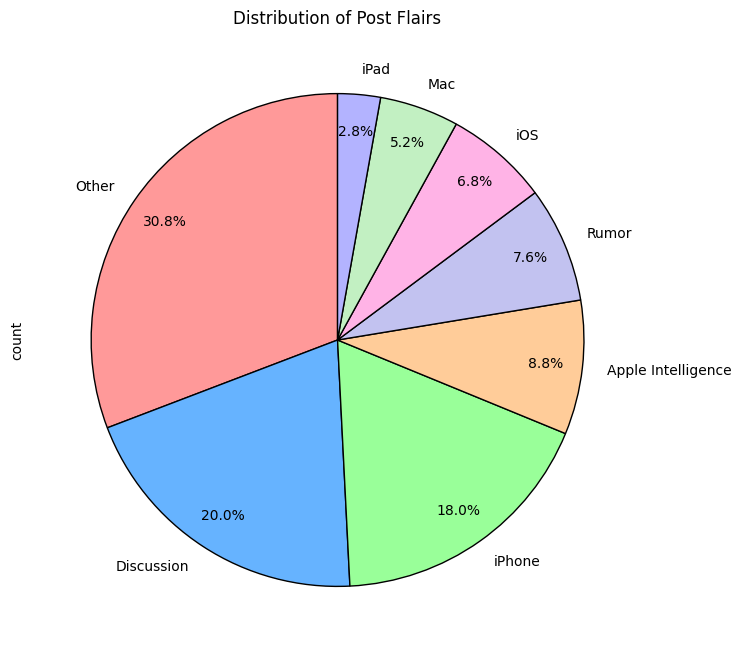

In [20]:
exclude_flair_none = top_reddit_posts[top_reddit_posts['Flair'] != 'None'].copy()

# Normalise text: remove spaces and standardise case (As some of flair have spacebar)
exclude_flair_none['Flair'] = exclude_flair_none['Flair'].str.strip()

main_flairs = [
    'iPhone',
    'Discussion',
    'iOS',
    'Mac',
    'Rumor',
    'iPad',
    'Apple Intelligence'
]

# Clean flairs
top_reddit_posts['Flair_Clean'] = exclude_flair_none['Flair'].copy()
top_reddit_posts['Flair_Clean'] = top_reddit_posts['Flair_Clean'].where(top_reddit_posts['Flair_Clean'].isin(main_flairs), other='Other')
top_reddit_posts = top_reddit_posts.copy()

# Count categories
count_flair = top_reddit_posts['Flair_Clean'].value_counts()

# Custom color palette (8 colors) 
colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c2f0c2', '#b3b3ff',
]

# Plot 
plt.figure(figsize=(11,8))
count_flair.plot(
    kind='pie',
    colors=colors[:len(count_flair)],  # Use only the number of categories
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Distribution of Post Flairs')
plt.show()

### 3.2.2 Upvotes by Flair

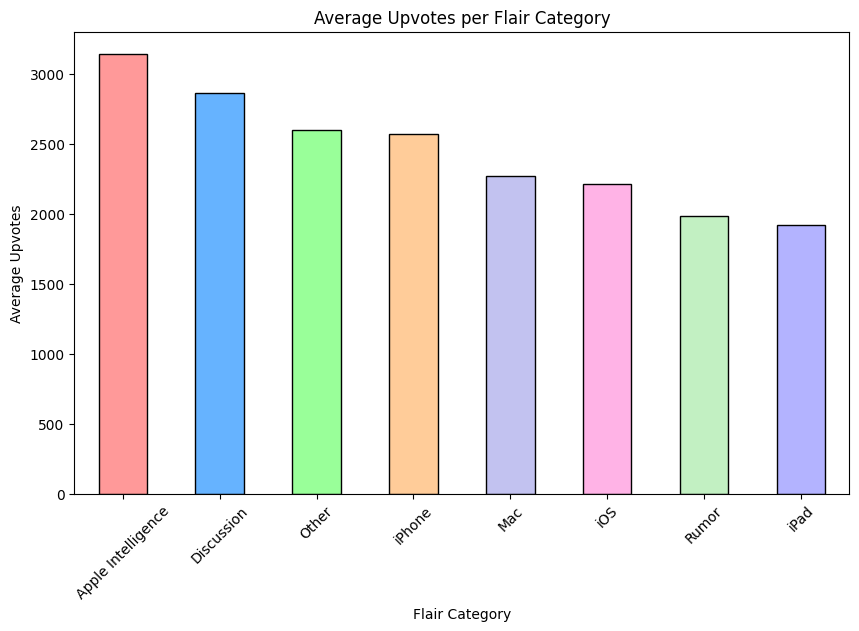

In [21]:
# Upvotes by Flair
Upvotes_By_Flair = top_reddit_posts.groupby('Flair_Clean')['Upvotes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
	'#ff9999',
    '#66b3ff', 
    '#99ff99', 
    '#ffcc99',
	'#c2c2f0', 
    '#ffb3e6', 
    '#c2f0c2', 
    '#b3b3ff',
]
Upvotes_By_Flair.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Upvotes per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.2.3 Number of Comments by Flair

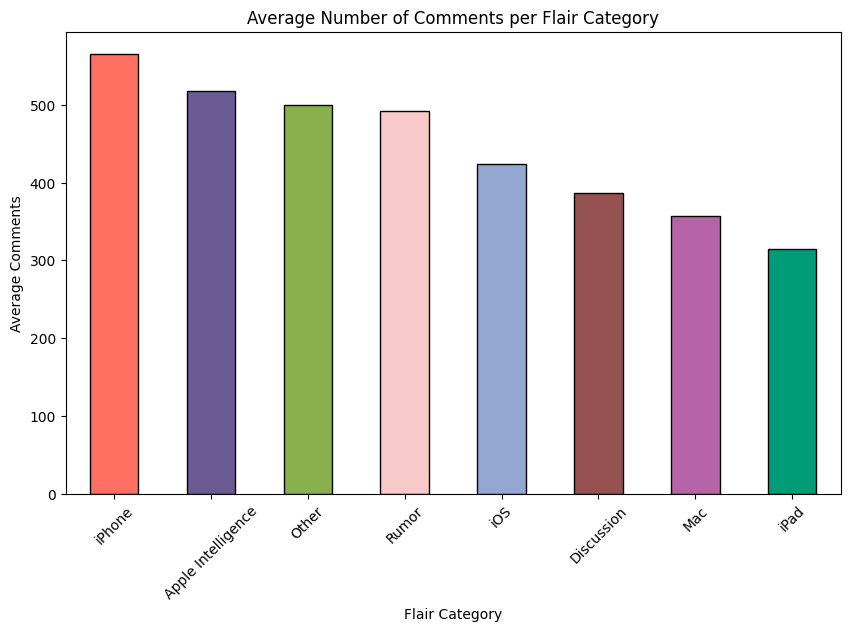

In [22]:
comments_by_flair = top_reddit_posts.groupby('Flair_Clean')['Num_Comments'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = [
    '#FF6F61',  
    '#6B5B95',  
    '#88B04B',  
    '#F7CAC9',  
    '#92A8D1',  
    '#955251',  
    '#B565A7',  
    '#009B77'   
]
comments_by_flair.plot(kind='bar', color= colors, edgecolor='black')

plt.title('Average Number of Comments per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Comments')
plt.xticks(rotation=45)
plt.show()

## 3.3 Text Analysis

In [23]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

### 3.3.1 Frequent Word Uses Chart

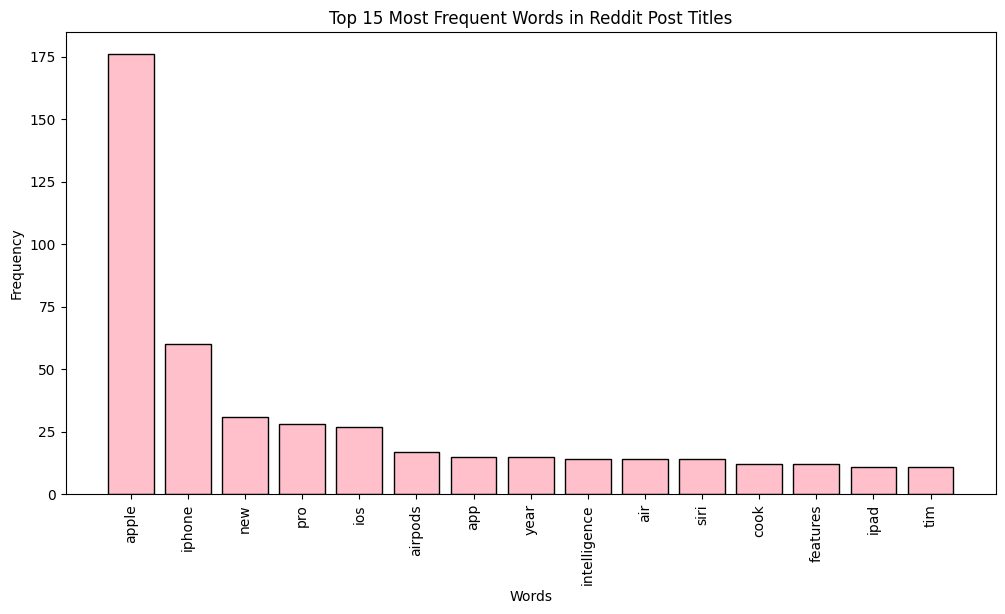

In [24]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = [] 

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    for w in set(tokens):   # unique per title
        words.append(w)

# Count word frequency
word_counts = Counter(words)

# Top 15 most frequent words
top_words = word_counts.most_common(15)


# Plot
plt.figure(figsize=(12, 6))
labels, counts = zip(*top_words)
plt.bar(labels, counts, 
        color= 'pink',
        edgecolor= 'black')
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### 3.3.2 Frequent Bigram Word (2-Word Combos)

In [25]:
from nltk.util import ngrams

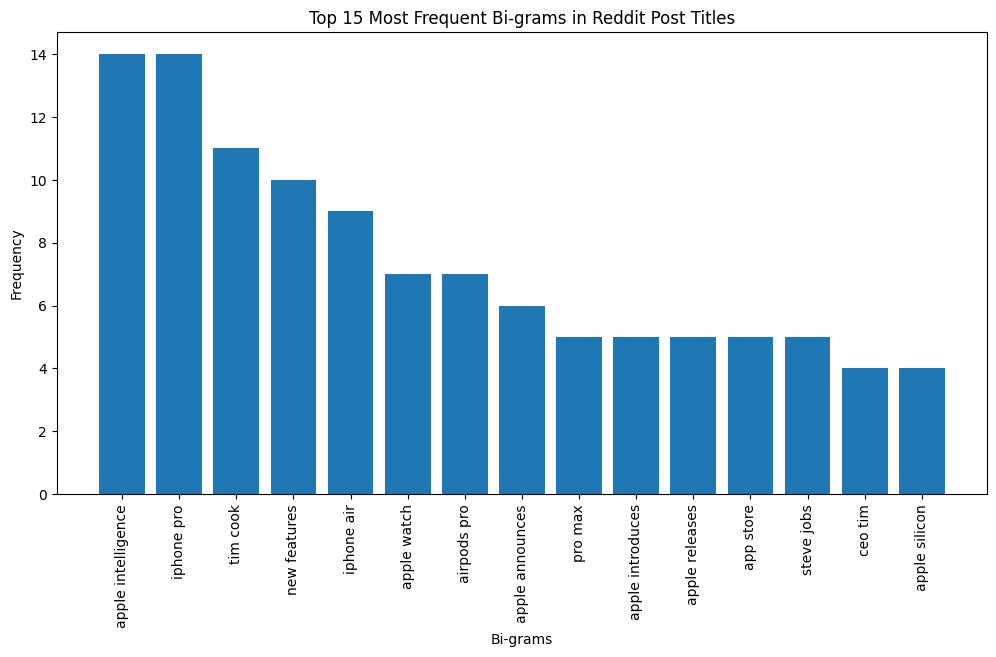

In [26]:
bigram_list = []

for t in title_clean:
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]
    bigrams_in_title = set(ngrams(tokens, 2))
    
    for bg in bigrams_in_title:
        bigram_list.append(bg)

# Count bi-gram frequency
bigram_counts = Counter(bigram_list)

# Top 15 bi-grams
top_bigrams = bigram_counts.most_common(15)

# Prepare labels
labels, counts = zip(*top_bigrams)
labels = [' '.join(bg) for bg in labels]  # ('apple','watch') -> 'apple watch'

# Plot
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Frequency')
plt.show()

### 3.3.3 Average Title Length Per Flair

In [27]:
top_reddit_posts['Title_Word_Count'].describe()

count    250.000000
mean      12.024000
std        5.157696
min        2.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       47.000000
Name: Title_Word_Count, dtype: float64

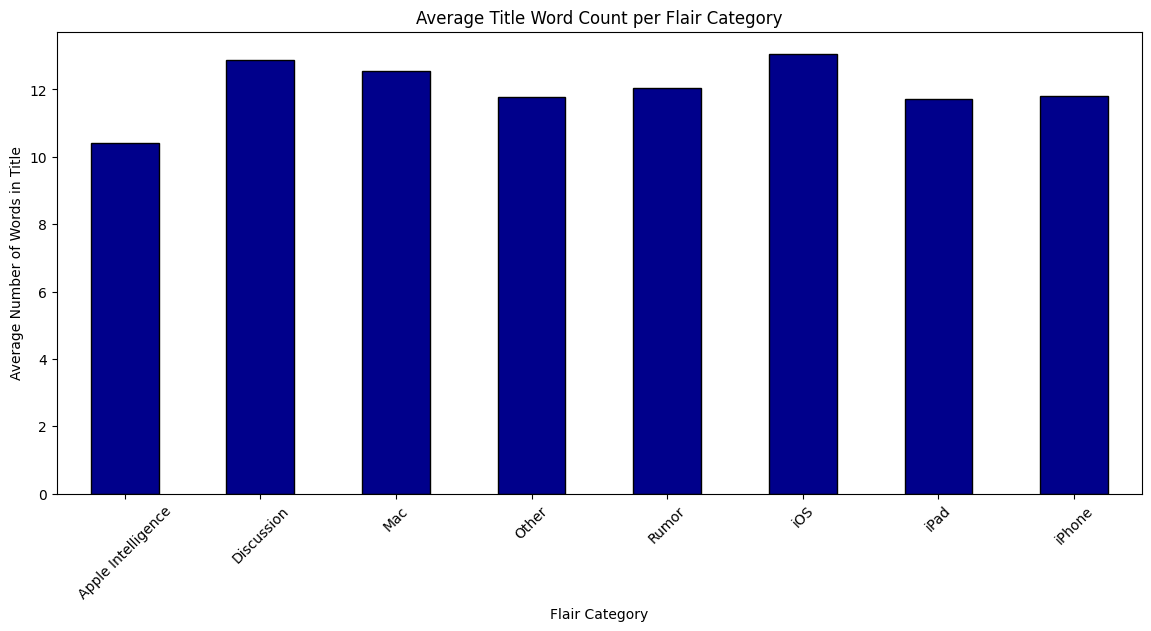

In [28]:
avg_title_length = top_reddit_posts.groupby('Flair_Clean')['Title_Word_Count'].mean()

plt.figure(figsize=(14,6))
avg_title_length.plot(kind='bar', color='darkblue', edgecolor='black')

plt.title('Average Title Word Count per Flair Category')
plt.xlabel('Flair Category')
plt.ylabel('Average Number of Words in Title')
plt.xticks(rotation=45)
plt.show()

## 3.4 Sentimental Analysis 

### 3.4.1 Sentimental Analysis Distribution

In [29]:
top_reddit_posts['Title_Sent'].value_counts()

Title_Sent
Neutral     121
Positive     72
Negative     57
Name: count, dtype: int64

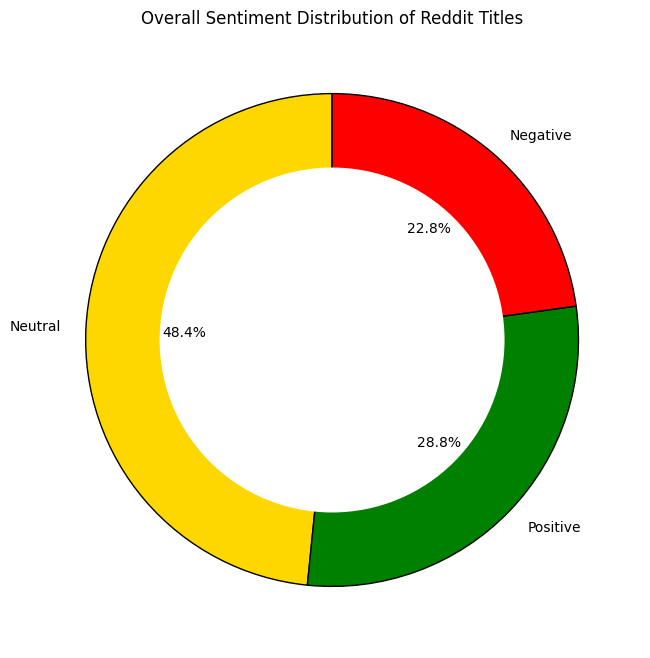

In [30]:
sentiment_counts = top_reddit_posts['Title_Sent'].value_counts()

# Colors (match your other charts)
colors = ['gold', 'green', 'red']  

plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Sentiment Distribution of Reddit Titles')
plt.show()

### 3.4.2 Relationship Between **Flair** and **Sentiment Analysis**

In [31]:
flair_sent = top_reddit_posts[top_reddit_posts['Flair'] != 'None']

# Group by Flair and Title_Sent and count posts
sentiment_flair_counts = (
    flair_sent
    .groupby(['Flair_Clean', 'Title_Sent'])
    .size()                       
    .unstack(fill_value=0)        
    .sort_index()                 
)

sentiment_flair_counts

Title_Sent,Negative,Neutral,Positive
Flair_Clean,,,
Apple Intelligence,9,3,10
Discussion,11,30,9
Mac,5,5,3
Other,10,32,24
Rumor,2,13,4
iOS,4,8,5
iPad,1,4,2
iPhone,14,20,11


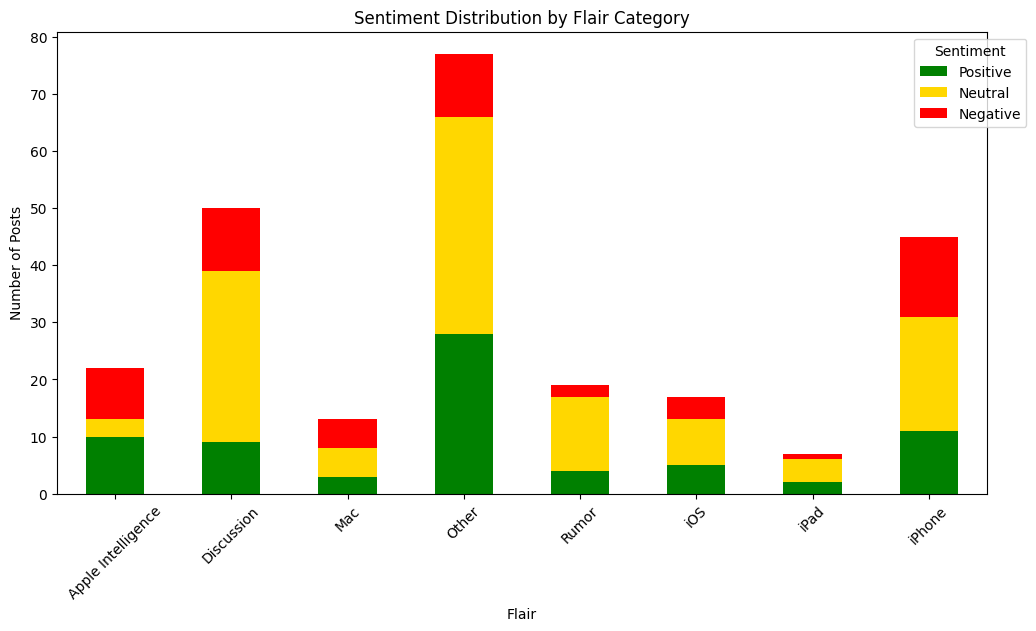

In [32]:
sentiment_by_flair = top_reddit_posts.groupby(
    ['Flair_Clean', 'Title_Sent']
).size().unstack(fill_value=0)

# Make sure columns appear in a fixed order
sentiment_by_flair = sentiment_by_flair[['Positive', 'Neutral', 'Negative']]

# Colors for each sentiment
sentiment_colors = {
    'Positive': 'green',
    'Neutral': 'gold',
    'Negative': 'red'
}

sentiment_by_flair.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=[sentiment_colors[col] for col in sentiment_by_flair.columns]
)

plt.title('Sentiment Distribution by Flair Category')
plt.xlabel('Flair')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()

### 3.4.3 Relationship Between **Frequent Words** and **Sentiment Analysis**

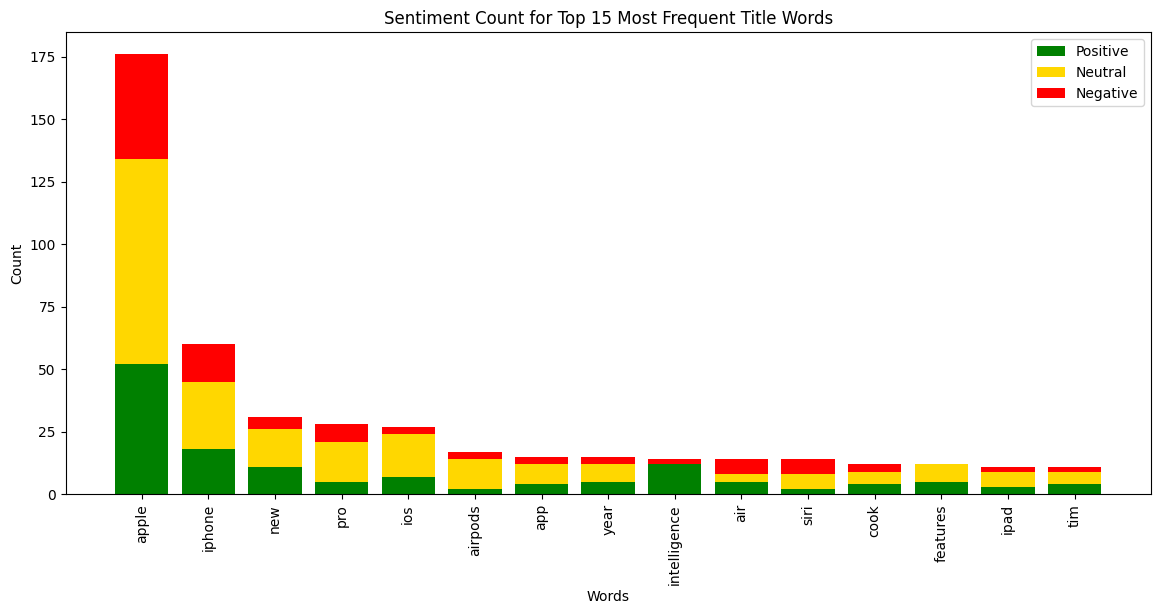

In [33]:
word_to_titles = {}  

for idx, t in enumerate(title_clean):
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            word_to_titles.setdefault(w, []).append(idx)


# Sentiment counting 
sentiment_counts = {w[0]: {'Positive': 0, 'Negative': 0, 'Neutral': 0} 
                    for w in top_words}

for word_tuple in top_words:
    word = word_tuple[0]
    rows = word_to_titles[word]  
    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts[word][sent] += 1


# Prepare plot data 
labels = [w[0] for w in top_words]
positive = [sentiment_counts[w]['Positive'] for w in labels]
negative = [sentiment_counts[w]['Negative'] for w in labels]
neutral  = [sentiment_counts[w]['Neutral']  for w in labels]


# Plot 
plt.figure(figsize=(14,6))

plt.bar(labels, positive, label='Positive', color='green')
plt.bar(labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(labels, negative, bottom=[positive[i] + neutral[i] for i in range(len(labels))], 
        label='Negative', color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Title Words')
plt.xlabel('Words')
plt.ylabel('Count')
plt.legend()
plt.show()

### 3.4.4 Relationship Between **Frequent Bigram** and **Sentiment Analysis**

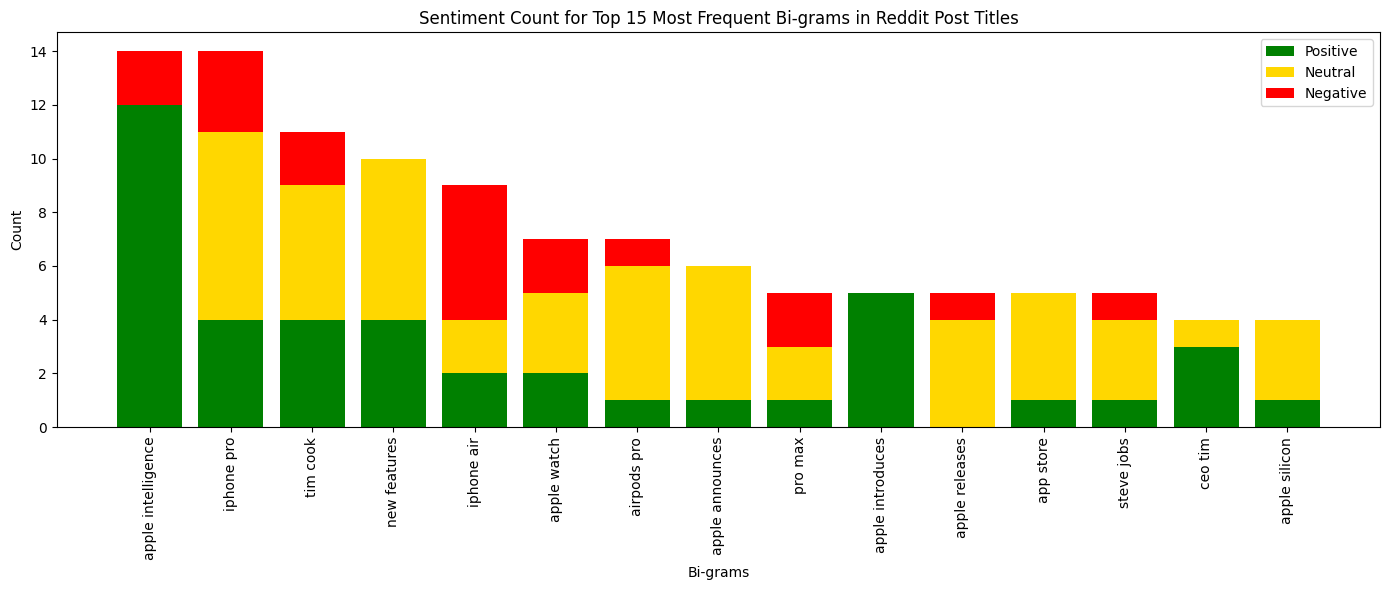

In [34]:
bigram_to_titles = {}
bigram_list = []

for idx, t in enumerate(title_clean):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', t)
    tokens = [w for w in tokens if w not in stop_words]

    # unique bigrams per title
    bigrams_in_title = set(ngrams(tokens, 2))

    for bg in bigrams_in_title:
        bigram_list.append(bg)
        bigram_to_titles.setdefault(bg, []).append(idx)

bigram_counts = Counter(bigram_list)

top_bigrams = bigram_counts.most_common(15)

# Convert bigrams to readable text labels
bg_labels = [' '.join(bg) for bg, _ in top_bigrams]

sentiment_counts_bg = {label: {'Positive': 0, 'Negative': 0, 'Neutral': 0}
                       for label in bg_labels}

for bg, _ in top_bigrams:
    label = ' '.join(bg)
    rows = bigram_to_titles[bg]

    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts_bg[label][sent] += 1

positive = [sentiment_counts_bg[w]['Positive'] for w in bg_labels]
neutral  = [sentiment_counts_bg[w]['Neutral']  for w in bg_labels]
negative = [sentiment_counts_bg[w]['Negative'] for w in bg_labels]


plt.figure(figsize=(14,6))

plt.bar(bg_labels, positive, label='Positive', color='green')
plt.bar(bg_labels, neutral,  bottom=positive, label='Neutral', color='gold')
plt.bar(bg_labels,
        negative,
        bottom=[positive[i] + neutral[i] for i in range(len(bg_labels))],
        label='Negative',
        color='red')

plt.xticks(rotation=90)
plt.title('Sentiment Count for Top 15 Most Frequent Bi-grams in Reddit Post Titles')
plt.xlabel('Bi-grams')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4.5 Relationship Between **Upvotes** and **Sentimental Analysis**

In [35]:
sentiment_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].agg(
    Count='count',
    Mean_Upvotes='mean',
    Median_Upvotes='median',
    Max_Upvotes='max'
)

print(sentiment_upvotes)

            Count  Mean_Upvotes  Median_Upvotes  Max_Upvotes
Title_Sent                                                  
Negative       57   2580.631579          2112.0         9872
Neutral       121   2467.471074          2070.0        13576
Positive       72   2783.875000          2005.0        11255


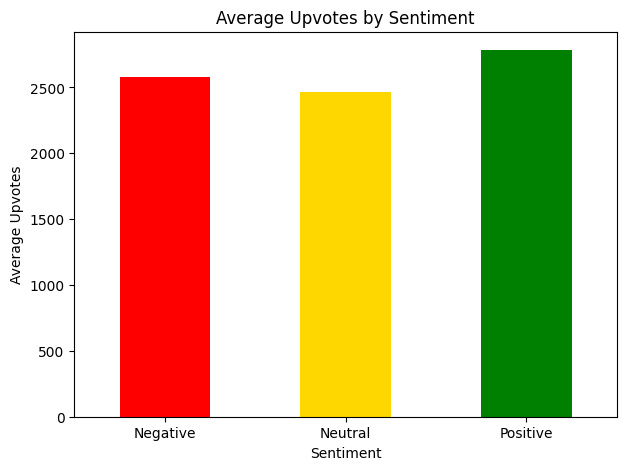

In [36]:
mean_upvotes = top_reddit_posts.groupby('Title_Sent')['Upvotes'].mean()

plt.figure(figsize=(7,5))
mean_upvotes.plot(kind='bar', color=['red','gold','green'])

plt.title('Average Upvotes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Upvotes')
plt.xticks(rotation=0)
plt.show()

## 3.5 Time-Series (UTC)

In [37]:
top_reddit_posts['Hour_Post'] = top_reddit_posts['Created_At'].dt.hour
top_reddit_posts['Day_of_Week'] = top_reddit_posts['Created_At'].dt.day_name()


In [38]:
# old_order ['Title', 'Upvotes', 'Flair', 'Flair_Clean', 'Num_Comments', 'Body', 'Created_UTC',
#        'Post_ID', 'Created_At', 'Created_Date', 'Created_Time',
#        'Title_compound', 'Title_Sent', 'Title_Word_Count', 'Body_Word_Count',
#        'Log_Upvotes', 'Log_Num_Comments', 'Log_Body_Word_Count', 'Flair_Clean',
#        'Hour_Post', 'Day_of_Week']

new_order = ['Title', 'Upvotes', 'Log_Upvotes', 'Flair', 'Flair_Clean' ,
      'Num_Comments', 'Log_Num_Comments', 'Body', 'Created_UTC',
      'Post_ID', 'Created_At', 'Created_Date', 'Day_of_Week', 'Created_Time', 'Hour_Post',
      'Title_Word_Count', 'Body_Word_Count', 'Log_Body_Word_Count', 'Title_compound', 'Title_Sent'
        ]

top_reddit_posts = top_reddit_posts[new_order]

### 3.5.1 Post Per Hour of the Day

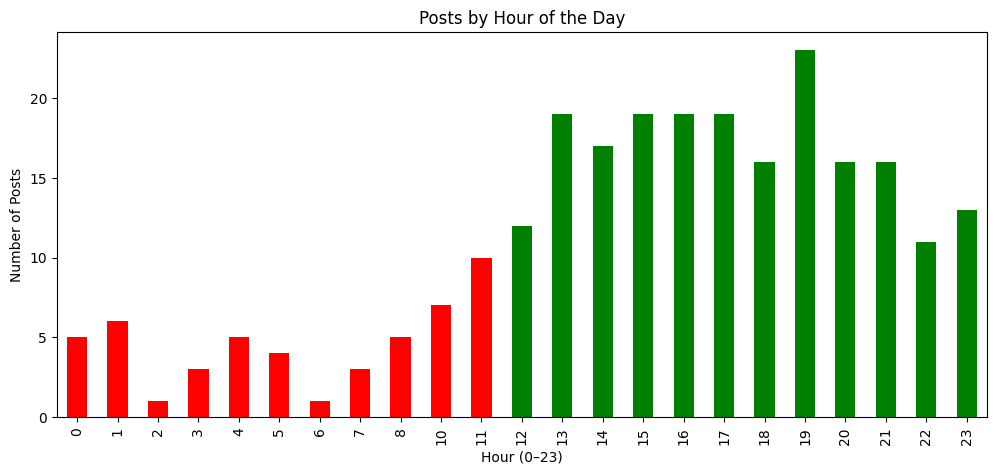

In [39]:
Posts_Per_Hour = top_reddit_posts['Hour_Post'].value_counts().sort_index()

# Choose color per hour: green for 12-23, red for 0-11
Colors_Hour = [
    'green' if h >= 12 
    else 'red' for h in Posts_Per_Hour.index
]

plt.figure(figsize=(12,5))
Posts_Per_Hour.plot(kind='bar', color= Colors_Hour)
plt.title('Posts by Hour of the Day')
plt.xlabel('Hour (0–23)') #12 AM - 11 PM
plt.ylabel('Number of Posts')
plt.show()

### 3.5.2 Post by Day of the Week

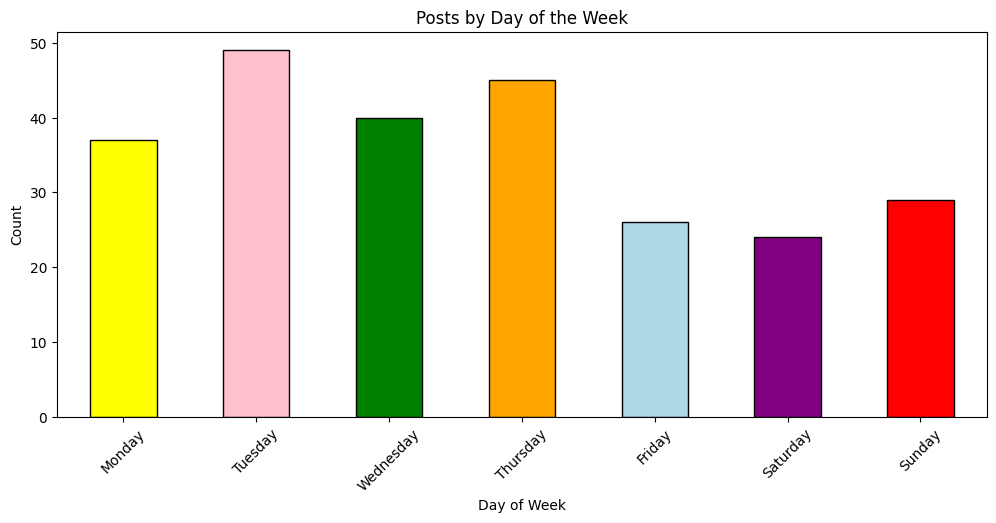

In [40]:
Posts_Per_Day_of_Week = top_reddit_posts['Day_of_Week'].value_counts().loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
]

# Create color mapping for Day_of_Weeks
colors_Day_of_Week = ['yellow', 'pink', 'green', 'orange', 'lightblue', 'purple', 'red']

plt.figure(figsize=(12, 5))
Posts_Per_Day_of_Week.plot(kind='bar', color=colors_Day_of_Week, edgecolor='black')

plt.title('Posts by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 3.5.3 Post over Year

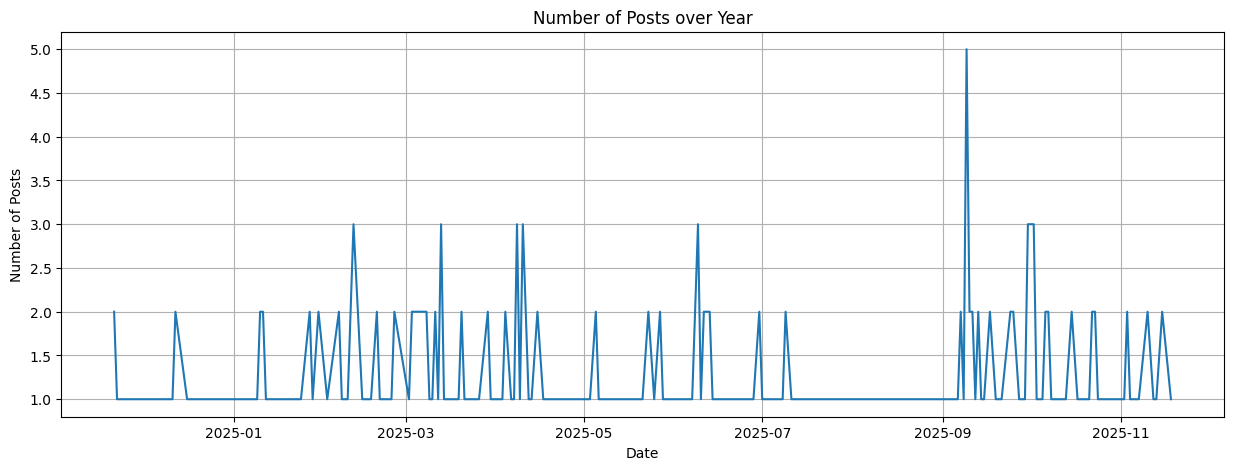

In [41]:
Posts_Per_Day = top_reddit_posts.groupby('Created_Date').size()

plt.figure(figsize=(15,5))
Posts_Per_Day.plot(kind='line')
plt.title('Number of Posts over Year')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True)
plt.show()

### 3.5.4 Monthly Post by Flair Trend

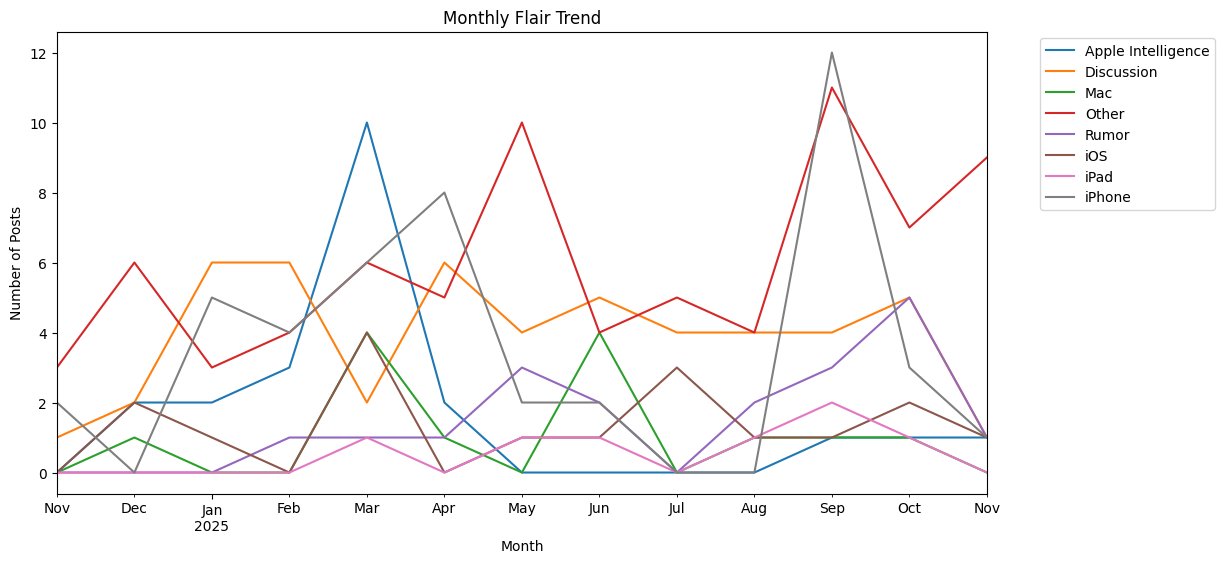

In [42]:
top_reddit_posts['Month'] = top_reddit_posts['Created_At'].dt.to_period('M').dt.to_timestamp()

Weekly_Trend = top_reddit_posts.groupby(['Month', 'Flair_Clean']).size().unstack(fill_value=0)

Weekly_Trend.plot(figsize=(12,6))
plt.title('Monthly Flair Trend')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### 3.5.5 Upvotes over Year

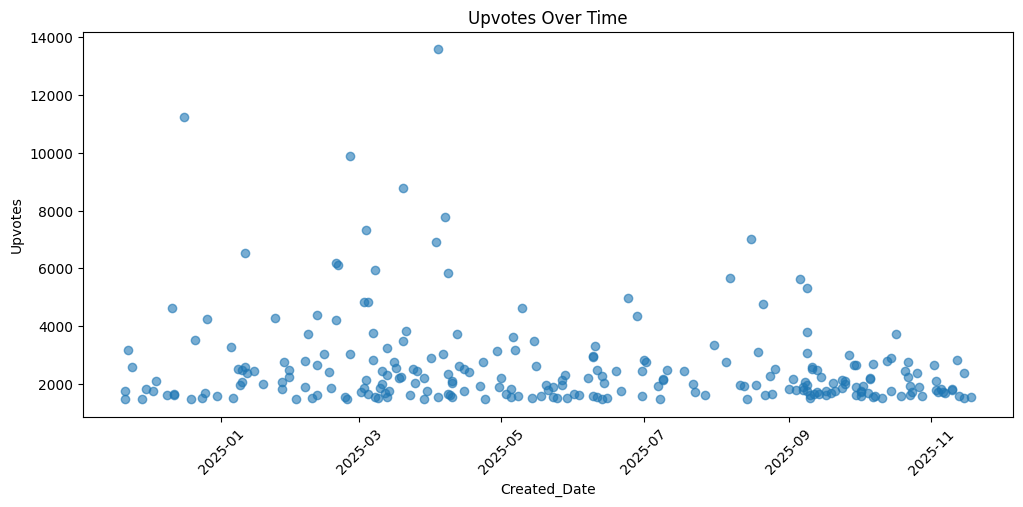

In [44]:
plt.figure(figsize=(12,5))
plt.scatter(
    top_reddit_posts['Created_Date'], 
    top_reddit_posts['Upvotes'], 
    alpha=0.6
)
plt.title('Upvotes Over Time')
plt.xlabel('Created_Date')
plt.ylabel('Upvotes')
plt.xticks(rotation=45)
plt.show()

### 3.5.6 Average Sentimental over Year

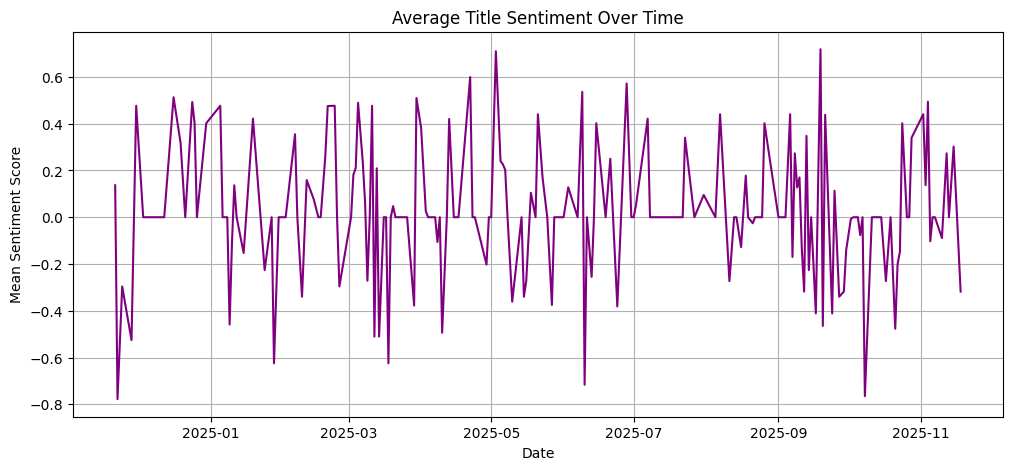

In [45]:
Sentiment_Over_Time = top_reddit_posts.groupby('Created_Date')['Title_compound'].mean()

plt.figure(figsize=(12,5))
Sentiment_Over_Time.plot(kind='line', color='purple')
plt.title('Average Title Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Score')
plt.grid(True)
plt.show()

# Step 4 : Ask a question about your data 

## **Does the mood tone of a Reddit post (from Sentimental Analysis) influence to the engagement (Upvotes & Comments)?**

### 4.1 Do positive posts receive more upvotes than negative or neutral mood posts? 